All series loaded.
  NDVI Amazon: train=251, test=48
  NDVI Sahel: train=251, test=48
  SST North Atlantic: train=252, test=48
  SST Indian Ocean: train=252, test=48

Simulating SARIMAX extension for NDVI Amazon...
  Real train obs:      251
  Synthetic obs added: 600
  Extended train obs:  851

Simulating SARIMAX extension for NDVI Sahel...
  Real train obs:      251
  Synthetic obs added: 600
  Extended train obs:  851


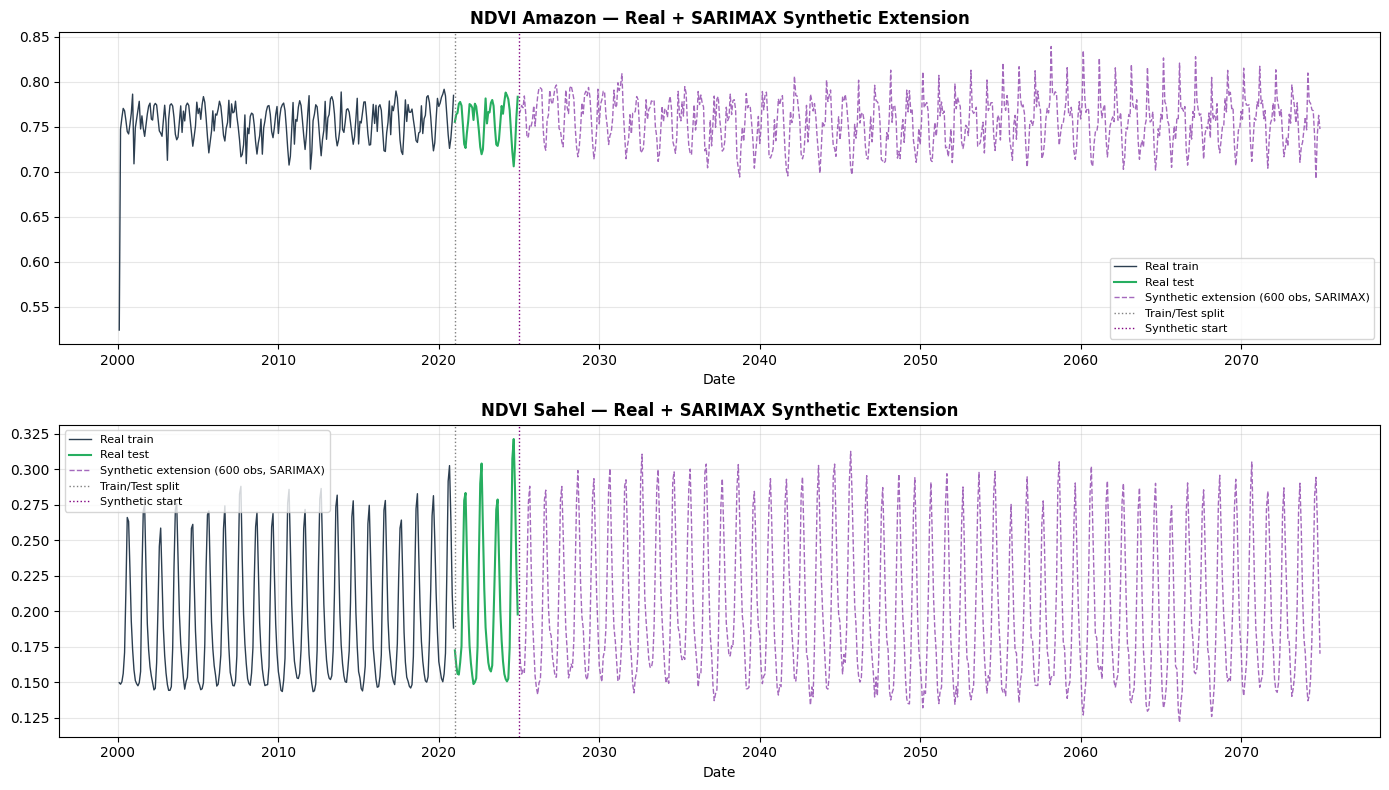


✓ NDVI synthetic extensions complete. Proceed to Cell 2 for SST.
  extended_trains keys so far: ['NDVI Amazon', 'NDVI Sahel']


In [7]:
# ============================================================
# Cell 1 — Synthetic Data Generation (NDVI series only)
# Strategy: Fit SARIMAX on full real data (train+test combined)
# then simulate 600 forward observations per NDVI series.
# Extended training set = real train + 600 synthetic obs.
# Test set remains the original real test — ground truth preserved.
# SST series handled separately in Cell 2 (empirical resampling).
# Reference: Box & Jenkins (1970); Seabold & Perktold (2010)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

DATA     = Path('../data/processed')
FIGURES  = Path('../outputs/figures')
OUTPUTS  = Path('../outputs')

# --- Load all series ---
ndvi_amazon_train  = pd.read_csv(DATA / 'ndvi_amazon_train.csv',  parse_dates=['date'])
ndvi_amazon_test   = pd.read_csv(DATA / 'ndvi_amazon_test.csv',   parse_dates=['date'])
ndvi_sahel_train   = pd.read_csv(DATA / 'ndvi_sahel_train.csv',   parse_dates=['date'])
ndvi_sahel_test    = pd.read_csv(DATA / 'ndvi_sahel_test.csv',    parse_dates=['date'])
sst_atlantic_train = pd.read_csv(DATA / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test  = pd.read_csv(DATA / 'sst_atlantic_test.csv',  parse_dates=['date'])
sst_indian_train   = pd.read_csv(DATA / 'sst_indian_train.csv',   parse_dates=['date'])
sst_indian_test    = pd.read_csv(DATA / 'sst_indian_test.csv',    parse_dates=['date'])

print("All series loaded.")
for name, tr, te in [
    ('NDVI Amazon',        ndvi_amazon_train,  ndvi_amazon_test),
    ('NDVI Sahel',         ndvi_sahel_train,   ndvi_sahel_test),
    ('SST North Atlantic', sst_atlantic_train, sst_atlantic_test),
    ('SST Indian Ocean',   sst_indian_train,   sst_indian_test),
]:
    print(f"  {name}: train={len(tr)}, test={len(te)}")

# ---------------------------------------------------------------
# SARIMAX simulation — NDVI only
# Fits on full series (train+test), simulates n_sim steps forward
# ---------------------------------------------------------------
def simulate_extension_sarimax(train, test, value_col, order, seasonal_order, n_sim=600):
    full = pd.concat([train, test], ignore_index=True).copy()
    full = full.sort_values('date').reset_index(drop=True)

    model = SARIMAX(
        full[value_col],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    sim = fit.simulate(nsimulations=n_sim, anchor='end')

    last_date = full['date'].iloc[-1]
    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=n_sim,
        freq='MS'
    )

    synthetic_df = pd.DataFrame({
        'date': future_dates,
        value_col: sim.values
    })

    return synthetic_df


# ---------------------------------------------------------------
# NDVI series configs
# Orders from SARIMAX V2 tuning
# ---------------------------------------------------------------
ndvi_configs = [
    {
        'name':           'NDVI Amazon',
        'train':          ndvi_amazon_train,
        'test':           ndvi_amazon_test,
        'value_col':      'ndvi_mean',
        'order':          (1, 0, 1),
        'seasonal_order': (1, 1, 1, 12),
    },
    {
        'name':           'NDVI Sahel',
        'train':          ndvi_sahel_train,
        'test':           ndvi_sahel_test,
        'value_col':      'ndvi_mean',
        'order':          (1, 0, 1),
        'seasonal_order': (1, 1, 1, 12),
    },
]

# ---------------------------------------------------------------
# Generate synthetic extensions for NDVI
# ---------------------------------------------------------------
extended_trains = {}

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, cfg in enumerate(ndvi_configs):
    name  = cfg['name']
    train = cfg['train']
    test  = cfg['test']
    vcol  = cfg['value_col']

    print(f"\nSimulating SARIMAX extension for {name}...")
    synthetic = simulate_extension_sarimax(
        train, test, vcol,
        cfg['order'], cfg['seasonal_order'], n_sim=600
    )

    extended_train = pd.concat([train, synthetic], ignore_index=True)
    extended_trains[name] = {
        'extended_train': extended_train,
        'test':           test,
        'value_col':      vcol,
        'synthetic':      synthetic,
    }

    print(f"  Real train obs:      {len(train)}")
    print(f"  Synthetic obs added: {len(synthetic)}")
    print(f"  Extended train obs:  {len(extended_train)}")

    ax = axes[i]
    ax.plot(train['date'], train[vcol],
            color='#2c3e50', linewidth=1, label='Real train')
    ax.plot(test['date'], test[vcol],
            color='#27ae60', linewidth=1.5, label='Real test')
    ax.plot(synthetic['date'], synthetic[vcol],
            color='#8e44ad', linewidth=1, alpha=0.8, linestyle='--',
            label='Synthetic extension (600 obs, SARIMAX)')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test split')
    ax.axvline(x=synthetic['date'].iloc[0], color='purple',
               linestyle=':', linewidth=1, label='Synthetic start')
    ax.set_title(f'{name} — Real + SARIMAX Synthetic Extension', fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'fig_synthetic_ndvi_extension.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ NDVI synthetic extensions complete. Proceed to Cell 2 for SST.")
print(f"  extended_trains keys so far: {list(extended_trains.keys())}")


Generating empirical extension for SST North Atlantic...
  Estimated trend: 0.00198 units/month (0.0237 units/year)
  Real train obs:      252
  Synthetic obs added: 600
  Extended train obs:  852
  Monthly stats (mean ± std):
    Month 01: 9.987 ± 0.195
    Month 02: 9.429 ± 0.146
    Month 03: 9.299 ± 0.156
    Month 04: 9.695 ± 0.172
    Month 05: 10.847 ± 0.175
    Month 06: 12.849 ± 0.256
    Month 07: 15.223 ± 0.321
    Month 08: 16.560 ± 0.324
    Month 09: 15.863 ± 0.289
    Month 10: 14.142 ± 0.248
    Month 11: 12.342 ± 0.226
    Month 12: 10.966 ± 0.198

Generating empirical extension for SST Indian Ocean...
  Estimated trend: 0.00203 units/month (0.0244 units/year)
  Real train obs:      252
  Synthetic obs added: 600
  Extended train obs:  852
  Monthly stats (mean ± std):
    Month 01: 27.798 ± 0.306
    Month 02: 28.021 ± 0.280
    Month 03: 28.552 ± 0.344
    Month 04: 29.025 ± 0.347
    Month 05: 28.877 ± 0.332
    Month 06: 28.055 ± 0.314
    Month 07: 27.282 ± 0.295

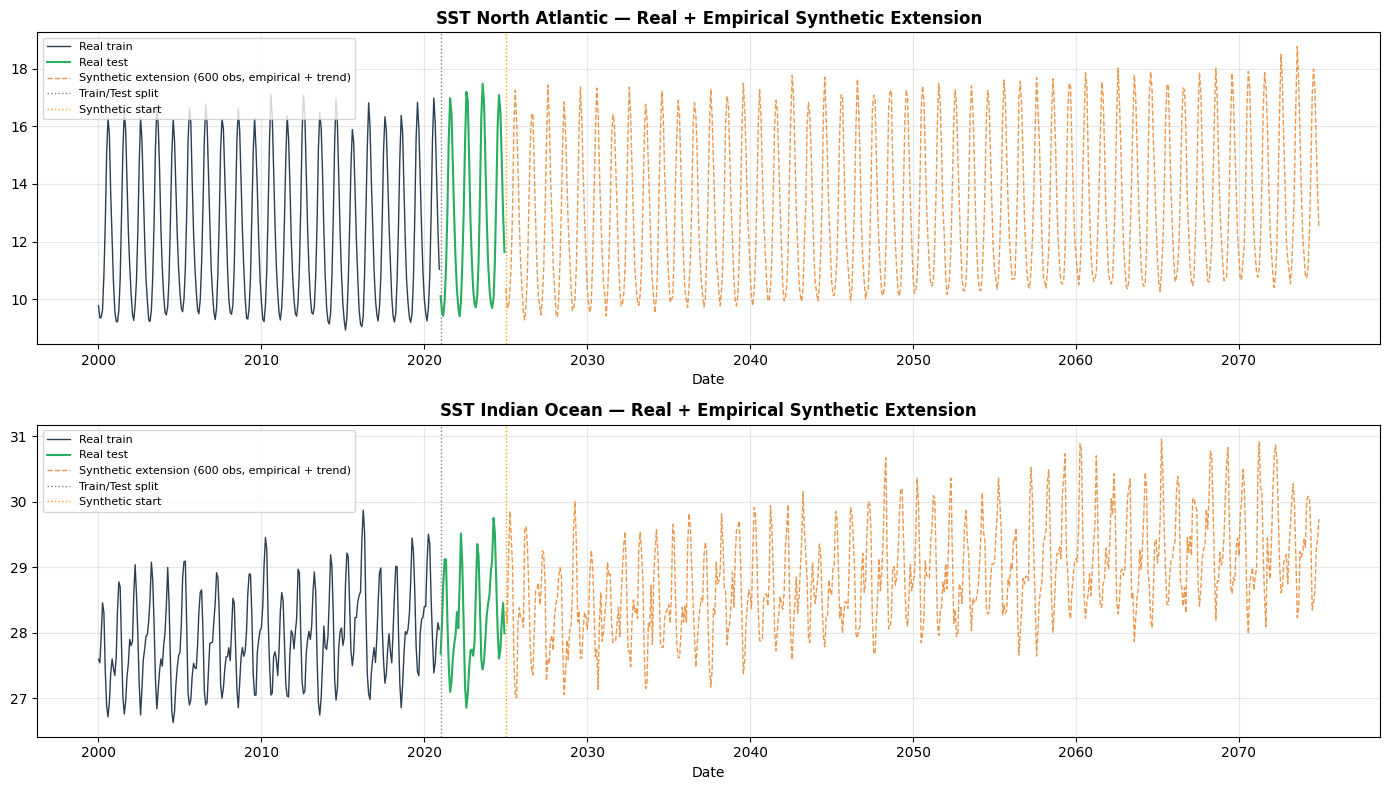


✓ SST synthetic extensions complete.
  extended_trains keys: ['NDVI Amazon', 'NDVI Sahel', 'SST North Atlantic', 'SST Indian Ocean']

All four series ready. Proceed to Cell 3 to re-run models.


In [12]:
# ============================================================
# Cell 2 — Synthetic Data Generation (SST series only)
# Strategy: Empirical monthly resampling from real training
# distributions with linear trend continuation.
# Preserves observed seasonal means, variance, inter-annual
# variability AND the warming trend present in real data.
# No drift accumulation — level anchored to real statistics.
# Extension: 240 obs (20 years) per SST series.
# ============================================================

np.random.seed(42)

# ---------------------------------------------------------------
# Empirical monthly resampling with trend
# For each synthetic month:
#   1. Look up real mean and std for that calendar month
#   2. Estimate linear trend from full real data and continue it
#   3. Sample from N(mean + trend, std) with AR(1) smoothing
# ---------------------------------------------------------------
def simulate_extension_empirical(train, test, value_col, n_sim=240, ar_coef=0.3):
    """
    Generates synthetic extension by resampling from empirical
    monthly distributions of the real training data, with linear
    trend continuation to preserve the warming signal in SST.

    Parameters:
        train     : real training DataFrame
        test      : real test DataFrame
        value_col : target column name
        n_sim     : number of synthetic observations to generate
        ar_coef   : AR(1) coefficient for temporal smoothness
    """
    full = pd.concat([train, test], ignore_index=True).copy()
    full = full.sort_values('date').reset_index(drop=True)
    full['month'] = full['date'].dt.month

    # Compute empirical monthly statistics from real training data only
    train_copy = train.copy()
    train_copy['month'] = train_copy['date'].dt.month
    monthly_stats = train_copy.groupby('month')[value_col].agg(['mean', 'std']).reset_index()
    monthly_stats.columns = ['month', 'monthly_mean', 'monthly_std']

    # Estimate linear trend from full real data (train + test)
    x = np.arange(len(full))
    trend_coef  = np.polyfit(x, full[value_col].values, 1)
    trend_slope = trend_coef[0]
    print(f"  Estimated trend: {trend_slope:.5f} units/month "
          f"({trend_slope * 12:.4f} units/year)")

    # Anchor point — last real value index for trend continuation
    last_real_idx = len(full) - 1
    last_date     = full['date'].iloc[-1]

    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=n_sim,
        freq='MS'
    )

    synthetic_values = []
    prev_residual = 0.0

    for step, date in enumerate(future_dates):
        month = date.month
        row   = monthly_stats[monthly_stats['month'] == month].iloc[0]
        mu    = row['monthly_mean']
        sigma = row['monthly_std']

        # Trend value at this future timestep
        future_idx      = last_real_idx + step + 1
        trend_value     = trend_coef[0] * future_idx + trend_coef[1]

        # Seasonal offset from monthly mean vs overall mean
        overall_mean    = full[value_col].mean()
        seasonal_offset = mu - overall_mean

        # Final value = trend continuation + seasonal offset + AR(1) noise
        noise         = np.random.normal(0, sigma)
        residual      = ar_coef * prev_residual + np.sqrt(1 - ar_coef**2) * noise
        value         = trend_value + seasonal_offset + residual
        prev_residual = residual

        # Clip to physically plausible range
        value = np.clip(value,
                        trend_value + seasonal_offset - 3 * sigma,
                        trend_value + seasonal_offset + 3 * sigma)
        synthetic_values.append(value)

    synthetic_df = pd.DataFrame({
        'date':    future_dates,
        value_col: synthetic_values
    })

    return synthetic_df, monthly_stats


# ---------------------------------------------------------------
# SST series configs
# ---------------------------------------------------------------
sst_configs = [
    {
        'name':      'SST North Atlantic',
        'train':     sst_atlantic_train,
        'test':      sst_atlantic_test,
        'value_col': 'sst_mean',
    },
    {
        'name':      'SST Indian Ocean',
        'train':     sst_indian_train,
        'test':      sst_indian_test,
        'value_col': 'sst_mean',
    },
]

# ---------------------------------------------------------------
# Generate synthetic extensions for SST
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, cfg in enumerate(sst_configs):
    name  = cfg['name']
    train = cfg['train']
    test  = cfg['test']
    vcol  = cfg['value_col']

    print(f"\nGenerating empirical extension for {name}...")
    synthetic, monthly_stats = simulate_extension_empirical(
        train, test, vcol, n_sim=600, ar_coef=0.3
    )

    extended_train = pd.concat([train, synthetic], ignore_index=True)
    extended_trains[name] = {
        'extended_train': extended_train,
        'test':           test,
        'value_col':      vcol,
        'synthetic':      synthetic,
    }

    print(f"  Real train obs:      {len(train)}")
    print(f"  Synthetic obs added: {len(synthetic)}")
    print(f"  Extended train obs:  {len(extended_train)}")
    print(f"  Monthly stats (mean ± std):")
    for _, row in monthly_stats.iterrows():
        print(f"    Month {int(row['month']):02d}: "
              f"{row['monthly_mean']:.3f} ± {row['monthly_std']:.3f}")

    ax = axes[i]
    ax.plot(train['date'], train[vcol],
            color='#2c3e50', linewidth=1, label='Real train')
    ax.plot(test['date'], test[vcol],
            color='#27ae60', linewidth=1.5, label='Real test')
    ax.plot(synthetic['date'], synthetic[vcol],
            color='#e67e22', linewidth=1, alpha=0.8, linestyle='--',
            label='Synthetic extension (600 obs, empirical + trend)')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test split')
    ax.axvline(x=synthetic['date'].iloc[0], color='orange',
               linestyle=':', linewidth=1, label='Synthetic start')
    ax.set_title(f'{name} — Real + Empirical Synthetic Extension',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'fig_synthetic_sst_extension.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ SST synthetic extensions complete.")
print(f"  extended_trains keys: {list(extended_trains.keys())}")
print("\nAll four series ready. Proceed to Cell 3 to re-run models.")

In [13]:
# ============================================================
# Cell 3 — Re-run deep learning models on extended training data
# Models: N-BEATS V3, TFT V2, Chronos-Bolt (zero-shot)
# Training: real train + synthetic extension (~850 obs)
# Test: original real test set — ground truth preserved
# ============================================================

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE as NF_MAE
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE as TFT_MAE
from lightning.pytorch.callbacks import EarlyStopping
import lightning.pytorch as pl
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch

pl.seed_everything(42)
torch.manual_seed(42)

def to_nf_format(extended_train, value_col, series_id):
    df = extended_train.copy()
    df = df.rename(columns={'date': 'ds', value_col: 'y'})
    df['unique_id'] = series_id
    df['ds'] = pd.to_datetime(df['ds'])
    return df[['unique_id', 'ds', 'y']]

def prepare_tft_extended(extended_train, test, value_col):
    tail = extended_train.tail(36).copy()
    full = pd.concat([tail, test], ignore_index=True)
    full['time_idx'] = range(len(full))
    full['group'] = 'series_1'
    full['month'] = full['date'].dt.month.astype(str)
    full['month_sin'] = np.sin(2 * np.pi * full['date'].dt.month / 12)
    full['month_cos'] = np.cos(2 * np.pi * full['date'].dt.month / 12)
    return full, 36

def run_nbeats_extended(extended_train, test, value_col, series_name):
    print(f"\n  N-BEATS V3 (extended) — {series_name}...")
    horizon  = len(test)
    train_nf = to_nf_format(extended_train, value_col, 'series_1')

    model = NBEATS(
        h=horizon,
        input_size=24,
        max_steps=500,
        stack_types=['trend', 'seasonality'],
        n_blocks=[3, 3],
        mlp_units=[[512, 512], [512, 512]],
        loss=NF_MAE(),
        learning_rate=1e-3,
        val_check_steps=50,
        early_stop_patience_steps=5,
        scaler_type='standard',
        enable_progress_bar=False,
    )

    nf = NeuralForecast(models=[model], freq='MS')
    nf.fit(train_nf, val_size=horizon)
    preds    = nf.predict()
    forecast = preds['NBEATS'].values[:horizon]
    actual   = test[value_col].values[:horizon]

    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    print(f"    MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return mae, rmse

def run_tft_extended(extended_train, test, value_col, series_name):
    print(f"\n  TFT V2 (extended) — {series_name}...")
    full, train_size  = prepare_tft_extended(extended_train, test, value_col)
    max_encoder_length    = 36
    max_prediction_length = len(test)

    training = TimeSeriesDataSet(
        full[full.time_idx < train_size],
        time_idx="time_idx",
        target=value_col,
        group_ids=["group"],
        min_encoder_length=max_encoder_length // 2,
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        static_categoricals=["group"],
        time_varying_known_categoricals=["month"],
        time_varying_known_reals=["relative_time_idx", "month_sin", "month_cos"],
        time_varying_unknown_reals=[value_col],
        target_normalizer=GroupNormalizer(groups=["group"]),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation   = TimeSeriesDataSet.from_dataset(
        training, full, predict=True, stop_randomization=True)
    train_loader = training.to_dataloader(train=True, batch_size=32, num_workers=0)
    val_loader   = validation.to_dataloader(train=False, batch_size=32, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.05,
        hidden_continuous_size=32,
        loss=TFT_MAE(),
        log_interval=10,
        reduce_on_plateau_patience=5,
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')
    trainer = pl.Trainer(
        max_epochs=150,
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        callbacks=[early_stop],
        accelerator='cpu',
    )
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

    predictions = tft.predict(
        val_loader, return_y=True,
        trainer_kwargs=dict(accelerator='cpu'))
    forecast = predictions.output.numpy().flatten()
    actual   = predictions.y[0].numpy().flatten()
    min_len  = min(len(forecast), len(actual), len(test))

    mae  = mean_absolute_error(actual[:min_len], forecast[:min_len])
    rmse = np.sqrt(mean_squared_error(actual[:min_len], forecast[:min_len]))
    print(f"    MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return mae, rmse

def run_chronos_extended(extended_train, test, value_col, series_name):
    print(f"\n  Chronos-Bolt (extended) — {series_name}...")
    from chronos import BaseChronosPipeline

    pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-bolt-small",
        device_map="cpu",
        torch_dtype=torch.float32,
    )

    context_vals = extended_train[value_col].values[-512:]
    context      = torch.tensor(context_vals, dtype=torch.float32).unsqueeze(0)
    horizon      = len(test)

    quantile_levels  = [0.1, 0.5, 0.9]
    quantiles, mean  = pipeline.predict_quantiles(
        inputs=context,
        prediction_length=horizon,
        quantile_levels=quantile_levels,
    )
    forecast = mean[0].numpy()
    actual   = test[value_col].values[:horizon]

    mae  = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    print(f"    MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    return mae, rmse

# ---------------------------------------------------------------
# Run all three models on all four series
# ---------------------------------------------------------------
results_synthetic = {}

for cfg in [
    {'name': 'NDVI Amazon',        'value_col': 'ndvi_mean'},
    {'name': 'NDVI Sahel',         'value_col': 'ndvi_mean'},
    {'name': 'SST North Atlantic', 'value_col': 'sst_mean'},
    {'name': 'SST Indian Ocean',   'value_col': 'sst_mean'},
]:
    name = cfg['name']
    vcol = cfg['value_col']
    ext  = extended_trains[name]['extended_train']
    test = extended_trains[name]['test']

    print(f"\n{'='*55}")
    print(f"Series: {name}  |  Extended train obs: {len(ext)}")
    print(f"{'='*55}")

    nbeats_mae,  nbeats_rmse  = run_nbeats_extended(ext, test, vcol, name)
    tft_mae,     tft_rmse     = run_tft_extended(ext, test, vcol, name)
    chronos_mae, chronos_rmse = run_chronos_extended(ext, test, vcol, name)

    results_synthetic[name] = {
        'NBEATS_MAE':   round(nbeats_mae,   4),
        'NBEATS_RMSE':  round(nbeats_rmse,  4),
        'TFT_MAE':      round(tft_mae,      4),
        'TFT_RMSE':     round(tft_rmse,     4),
        'Chronos_MAE':  round(chronos_mae,  4),
        'Chronos_RMSE': round(chronos_rmse, 4),
    }

print("\n\n=== SYNTHETIC EXPERIMENT RAW RESULTS ===")
for name, res in results_synthetic.items():
    print(f"\n{name}")
    for k, v in res.items():
        print(f"  {k}: {v}")

Seed set to 42
Seed set to 1



Series: NDVI Amazon  |  Extended train obs: 851

  N-BEATS V3 (extended) — NDVI Amazon...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  3.5 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 3.5 M                                                                                            
Non-trainable params: 21.0 K                                                                                       
Total params: 3.5 M                                                                                                
Total estimated model params size (MB): 14                                                                         
Modules in train mode: 52                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Trainable params: 3.5 M                                                                                            
Non-trainable params: 21.0 K                                                                                       
Total params: 3.5 M                                                                                                
Total estimated model params size (MB): 14                                                                         
Modules in train mode: 52                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

    MAE: 1.2078 | RMSE: 1.2825

  TFT V2 (extended) — SST Indian Ocean...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


    MAE: 1.1722 | RMSE: 1.2804

  Chronos-Bolt (extended) — SST Indian Ocean...
    MAE: 1.2470 | RMSE: 1.2824


=== SYNTHETIC EXPERIMENT RAW RESULTS ===

NDVI Amazon
  NBEATS_MAE: 0.0142
  NBEATS_RMSE: 0.0187
  TFT_MAE: 0.014
  TFT_RMSE: 0.018
  Chronos_MAE: 0.0122
  Chronos_RMSE: 0.0175

NDVI Sahel
  NBEATS_MAE: 0.0142
  NBEATS_RMSE: 0.0166
  TFT_MAE: 0.0101
  TFT_RMSE: 0.0123
  Chronos_MAE: 0.0106
  Chronos_RMSE: 0.0129

SST North Atlantic
  NBEATS_MAE: 1.1247
  NBEATS_RMSE: 1.1472
  TFT_MAE: 1.1662
  TFT_RMSE: 1.2005
  Chronos_MAE: 1.1099
  Chronos_RMSE: 1.139

SST Indian Ocean
  NBEATS_MAE: 1.2078
  NBEATS_RMSE: 1.2825
  TFT_MAE: 1.1722
  TFT_RMSE: 1.2804
  Chronos_MAE: 1.247
  Chronos_RMSE: 1.2824


Series                 Model        Real MAE  Synth MAE     Change
NDVI Amazon            N-BEATS        0.0200     0.0142    -29.0% ↓ better
NDVI Amazon            TFT            0.0085     0.0140    +64.7% ↑ worse
NDVI Amazon            Chronos        0.0231     0.0122    -47.2% ↓ better
---------------------------------------------------------------------------
NDVI Sahel             N-BEATS        0.0157     0.0142     -9.6% ↓ better
NDVI Sahel             TFT            0.0104     0.0101     -2.9% ↓ better
NDVI Sahel             Chronos        0.0136     0.0106    -22.1% ↓ better
---------------------------------------------------------------------------
SST North Atlantic     N-BEATS        0.3084     1.1247   +264.7% ↑ worse
SST North Atlantic     TFT            0.4135     1.1662   +182.0% ↑ worse
SST North Atlantic     Chronos        0.3476     1.1099   +219.3% ↑ worse
---------------------------------------------------------------------------
SST Indian Ocean       N-BEATS    

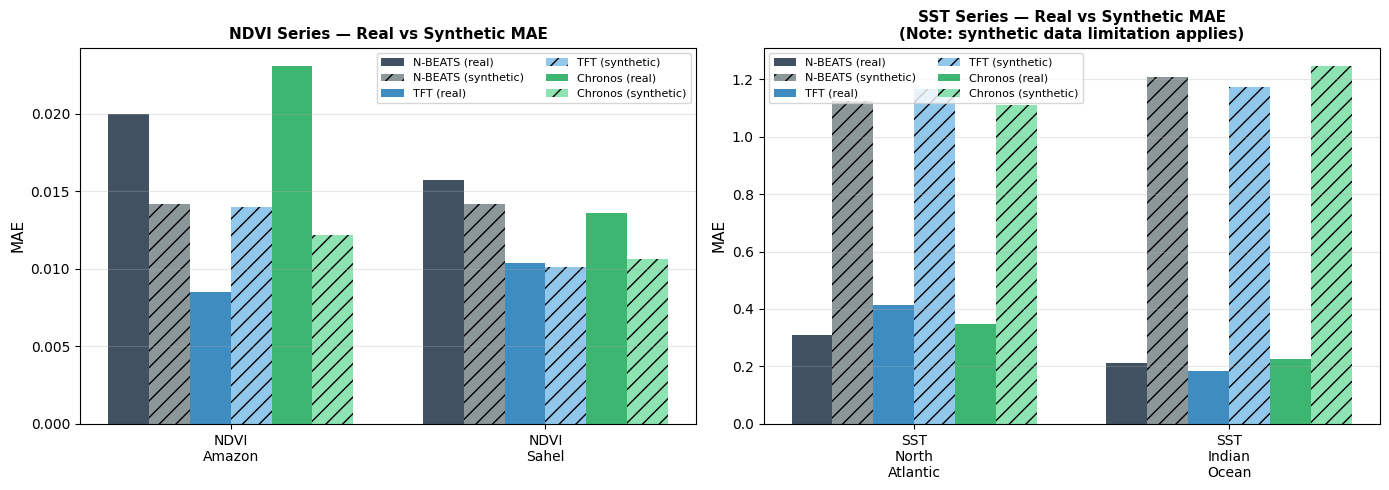

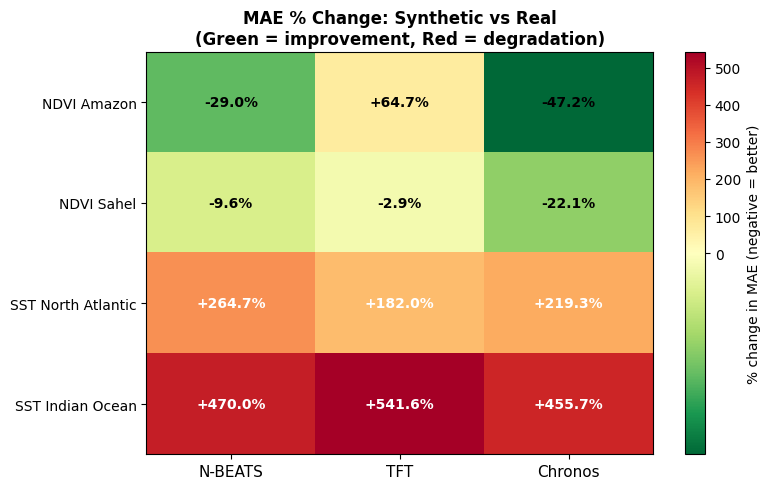


✓ Synthetic experiment visualisations saved.
  fig_synthetic_comparison_bars.png
  fig_synthetic_heatmap.png


In [14]:
# ============================================================
# Cell 4 — Synthetic Experiment Comparison Table + Chart
# Compares real-data MAE vs synthetic-extended MAE
# for N-BEATS V3, TFT V2, Chronos-Bolt across all four series
# ============================================================

# Real-data baseline MAE (from original experiments)
real_mae = {
    'NDVI Amazon': {
        'N-BEATS':  0.0200,
        'TFT':      0.0085,
        'Chronos':  0.0231,
    },
    'NDVI Sahel': {
        'N-BEATS':  0.0157,
        'TFT':      0.0104,
        'Chronos':  0.0136,
    },
    'SST North Atlantic': {
        'N-BEATS':  0.3084,
        'TFT':      0.4135,
        'Chronos':  0.3476,
    },
    'SST Indian Ocean': {
        'N-BEATS':  0.2119,
        'TFT':      0.1827,
        'Chronos':  0.2244,
    },
}

# Synthetic-extended MAE (from Cell 3)
synth_mae = {
    'NDVI Amazon': {
        'N-BEATS':  0.0142,
        'TFT':      0.0140,
        'Chronos':  0.0122,
    },
    'NDVI Sahel': {
        'N-BEATS':  0.0142,
        'TFT':      0.0101,
        'Chronos':  0.0106,
    },
    'SST North Atlantic': {
        'N-BEATS':  1.1247,
        'TFT':      1.1662,
        'Chronos':  1.1099,
    },
    'SST Indian Ocean': {
        'N-BEATS':  1.2078,
        'TFT':      1.1722,
        'Chronos':  1.2470,
    },
}

models  = ['N-BEATS', 'TFT', 'Chronos']
series  = list(real_mae.keys())

# ---------------------------------------------------------------
# Print comparison table
# ---------------------------------------------------------------
print("=" * 75)
print(f"{'Series':<22} {'Model':<10} {'Real MAE':>10} {'Synth MAE':>10} {'Change':>10}")
print("=" * 75)

for s in series:
    for m in models:
        r  = real_mae[s][m]
        sy = synth_mae[s][m]
        pct_change = ((sy - r) / r) * 100
        direction  = "↓ better" if pct_change < 0 else "↑ worse"
        print(f"{s:<22} {m:<10} {r:>10.4f} {sy:>10.4f} "
              f"{pct_change:>+8.1f}% {direction}")
    print("-" * 75)

# ---------------------------------------------------------------
# Figure 1 — NDVI series bar chart (real vs synthetic)
# SST shown separately due to scale difference
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ndvi_series = ['NDVI Amazon', 'NDVI Sahel']
sst_series  = ['SST North Atlantic', 'SST Indian Ocean']

bar_width = 0.13
colors_real  = ['#2c3e50', '#2980b9', '#27ae60']
colors_synth = ['#7f8c8d', '#85c1e9', '#82e0aa']

for ax, series_group, title in zip(
    axes,
    [ndvi_series, sst_series],
    ['NDVI Series — Real vs Synthetic MAE',
     'SST Series — Real vs Synthetic MAE\n(Note: synthetic data limitation applies)']
):
    x = np.arange(len(series_group))

    for j, (model, cr, cs) in enumerate(zip(models, colors_real, colors_synth)):
        offsets = (j - 1) * bar_width * 2

        real_vals  = [real_mae[s][model]  for s in series_group]
        synth_vals = [synth_mae[s][model] for s in series_group]

        bars_real  = ax.bar(x + offsets - bar_width / 2, real_vals,
                            bar_width, label=f'{model} (real)',
                            color=cr, alpha=0.9)
        bars_synth = ax.bar(x + offsets + bar_width / 2, synth_vals,
                            bar_width, label=f'{model} (synthetic)',
                            color=cs, alpha=0.9, hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(' ', '\n') for s in series_group], fontsize=10)
    ax.set_ylabel('MAE', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES / 'fig_synthetic_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# Figure 2 — Percentage change heatmap
# ---------------------------------------------------------------
import matplotlib.colors as mcolors

pct_matrix = np.zeros((len(series), len(models)))
for i, s in enumerate(series):
    for j, m in enumerate(models):
        r  = real_mae[s][m]
        sy = synth_mae[s][m]
        pct_matrix[i, j] = ((sy - r) / r) * 100

fig, ax = plt.subplots(figsize=(8, 5))

# Diverging colormap: green = improvement, red = degradation
norm = mcolors.TwoSlopeNorm(vmin=pct_matrix.min(), vcenter=0, vmax=pct_matrix.max())
im   = ax.imshow(pct_matrix, cmap='RdYlGn_r', norm=norm, aspect='auto')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=11)
ax.set_yticks(range(len(series)))
ax.set_yticklabels(series, fontsize=10)
ax.set_title('MAE % Change: Synthetic vs Real\n'
             '(Green = improvement, Red = degradation)',
             fontweight='bold')

# Annotate cells
for i in range(len(series)):
    for j in range(len(models)):
        val  = pct_matrix[i, j]
        sign = '+' if val > 0 else ''
        ax.text(j, i, f'{sign}{val:.1f}%',
                ha='center', va='center', fontsize=10,
                fontweight='bold',
                color='white' if abs(val) > 100 else 'black')

plt.colorbar(im, ax=ax, label='% change in MAE (negative = better)')
plt.tight_layout()
plt.savefig(FIGURES / 'fig_synthetic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Synthetic experiment visualisations saved.")
print("  fig_synthetic_comparison_bars.png")
print("  fig_synthetic_heatmap.png")

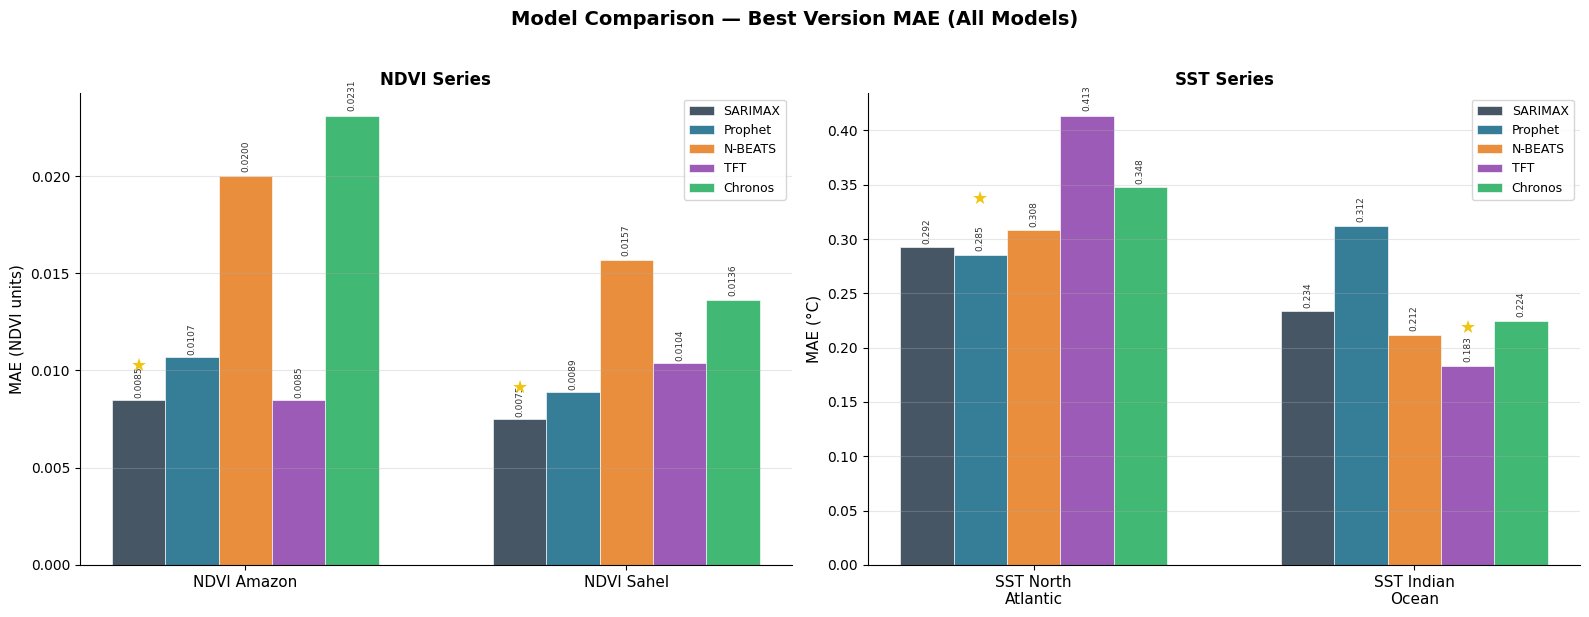

✓ Saved: fig_comparison_all_models.png


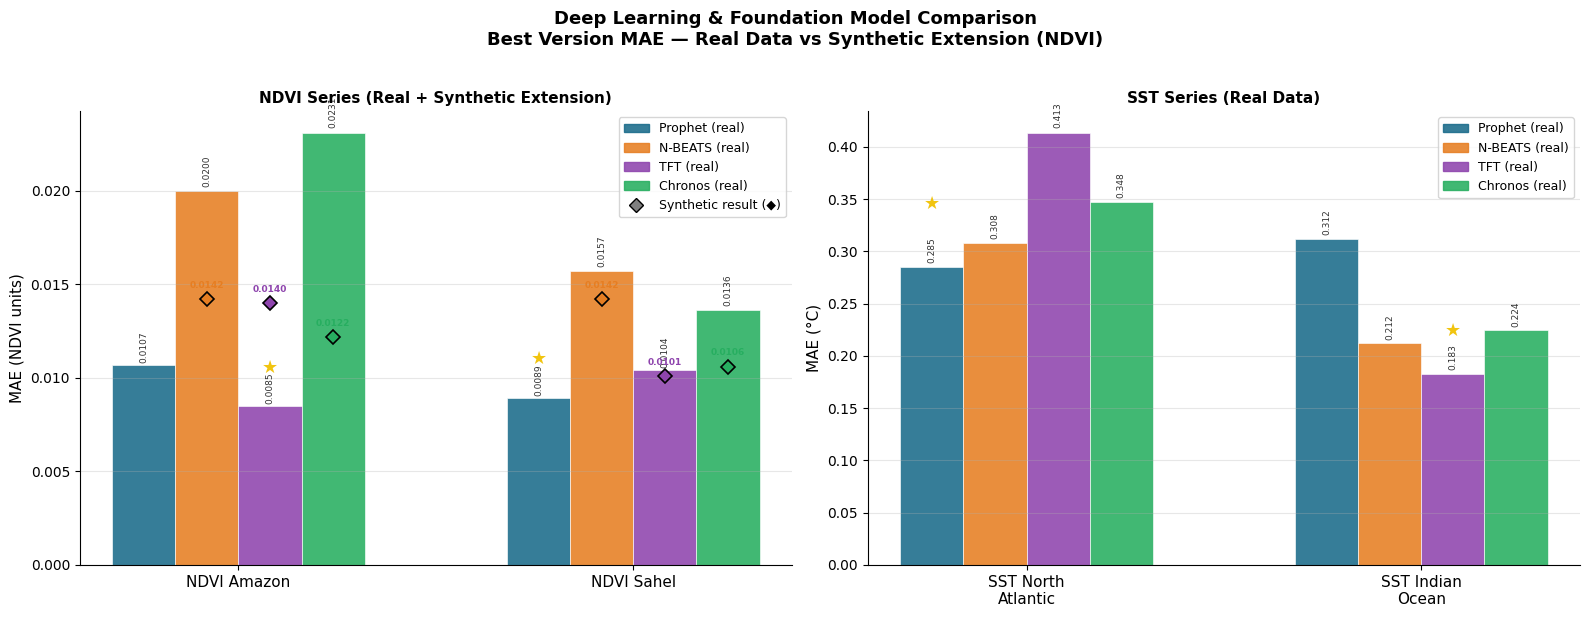

✓ Saved: fig_comparison_no_sarimax.png


In [15]:
# ============================================================
# Cell 5 — Final Comparison Visualisations
# Two figures:
#   Fig A: All 6 models including SARIMAX (full picture)
#   Fig B: Excluding SARIMAX (deep learning focus)
# Best version per model used throughout.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FIGURES = Path('../outputs/figures')

# ---------------------------------------------------------------
# Data — best version MAE per model per series
# ---------------------------------------------------------------
series_labels = ['NDVI Amazon', 'NDVI Sahel', 'SST North\nAtlantic', 'SST Indian\nOcean']
series_keys   = ['NDVI Amazon', 'NDVI Sahel', 'SST North Atlantic', 'SST Indian Ocean']

best_mae = {
    'SARIMAX':  [0.0085, 0.0075, 0.2924, 0.2339],
    'Prophet':  [0.0107, 0.0089, 0.2855, 0.3123],
    'N-BEATS':  [0.0200, 0.0157, 0.3084, 0.2119],
    'TFT':      [0.0085, 0.0104, 0.4135, 0.1827],
    'Chronos':  [0.0231, 0.0136, 0.3476, 0.2244],
}

synth_mae = {
    'N-BEATS':  [0.0142, 0.0142, None, None],
    'TFT':      [0.0140, 0.0101, None, None],
    'Chronos':  [0.0122, 0.0106, None, None],
}

# Colour palette
palette = {
    'SARIMAX': '#2c3e50',
    'Prophet': '#1a6b8a',
    'N-BEATS': '#e67e22',
    'TFT':     '#8e44ad',
    'Chronos': '#27ae60',
}

# ---------------------------------------------------------------
# Helper — annotate winner per series
# ---------------------------------------------------------------
def annotate_winners(ax, data_dict, series_idx, x_positions, bar_width, n_models):
    for si in series_idx:
        vals   = {m: v[si] for m, v in data_dict.items() if v[si] is not None}
        winner = min(vals, key=vals.get)
        win_val = vals[winner]
        models_list = list(data_dict.keys())
        mi = models_list.index(winner)
        x  = x_positions[si] + (mi - (n_models - 1) / 2) * bar_width
        ax.annotate('★', xy=(x, win_val),
                     ha='center', va='bottom',
                    fontsize=11, color='gold',
                    fontweight='bold')

# ===============================================================
# FIGURE A — All 6 models including SARIMAX
# ===============================================================
models_A  = ['SARIMAX', 'Prophet', 'N-BEATS', 'TFT', 'Chronos']
n_models_A = len(models_A)
bar_width_A = 0.14
x = np.arange(len(series_keys))

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [1, 1]})
fig.suptitle('Model Comparison — Best Version MAE (All Models)',
             fontsize=14, fontweight='bold', y=1.02)

for ax_idx, (series_subset, title, ylabel) in enumerate([
    ([0, 1], 'NDVI Series', 'MAE (NDVI units)'),
    ([2, 3], 'SST Series',  'MAE (°C)'),
]):
    ax = axes[ax_idx]
    x_sub = np.arange(len(series_subset))

    for mi, model in enumerate(models_A):
        offset = (mi - (n_models_A - 1) / 2) * bar_width_A
        vals   = [best_mae[model][si] for si in series_subset]
        bars   = ax.bar(x_sub + offset, vals, bar_width_A,
                        label=model,
                        color=palette[model],
                        alpha=0.88,
                        edgecolor='white',
                        linewidth=0.5)
        # Value labels on bars
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    f'{val:.4f}' if ax_idx == 0 else f'{val:.3f}',
                    ha='center', va='bottom',
                    fontsize=6.5, rotation=90, color='#333333')

    # Star winner
    for plot_idx, si in enumerate(series_subset):
        vals_dict = {m: best_mae[m][si] for m in models_A}
        winner    = min(vals_dict, key=vals_dict.get)
        mi        = models_A.index(winner)
        offset    = (mi - (n_models_A - 1) / 2) * bar_width_A
        win_val   = vals_dict[winner]
        ax.annotate('★', xy=(plot_idx + offset, win_val * 1.15),
                    ha='center', va='bottom',
                    fontsize=13, color='#f1c40f', fontweight='bold')

    ax.set_xticks(x_sub)
    ax.set_xticklabels([series_labels[si] for si in series_subset], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / 'fig_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_comparison_all_models.png")

# ===============================================================
# FIGURE B — Excluding SARIMAX, with synthetic overlay for NDVI
# ===============================================================
models_B   = ['Prophet', 'N-BEATS', 'TFT', 'Chronos']
n_models_B = len(models_B)
bar_width_B = 0.16

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Deep Learning & Foundation Model Comparison\n'
             'Best Version MAE — Real Data vs Synthetic Extension (NDVI)',
             fontsize=13, fontweight='bold', y=1.02)

for ax_idx, (series_subset, title, ylabel) in enumerate([
    ([0, 1], 'NDVI Series (Real + Synthetic Extension)', 'MAE (NDVI units)'),
    ([2, 3], 'SST Series (Real Data)',                   'MAE (°C)'),
]):
    ax = axes[ax_idx]
    x_sub = np.arange(len(series_subset))

    for mi, model in enumerate(models_B):
        offset = (mi - (n_models_B - 1) / 2) * bar_width_B
        vals   = [best_mae[model][si] for si in series_subset]

        bars = ax.bar(x_sub + offset, vals, bar_width_B,
                      label=f'{model} (real)',
                      color=palette[model],
                      alpha=0.88,
                      edgecolor='white',
                      linewidth=0.5)

        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.01,
                    f'{val:.4f}' if ax_idx == 0 else f'{val:.3f}',
                    ha='center', va='bottom',
                    fontsize=6.5, rotation=90, color='#333333')

        # Synthetic overlay for NDVI only (models that have synth data)
        if ax_idx == 0 and model in synth_mae:
            synth_vals = [synth_mae[model][si] for si in series_subset]
            for plot_idx, (sv, bar) in enumerate(zip(synth_vals, bars)):
                if sv is not None:
                    ax.plot(
                        bar.get_x() + bar.get_width() / 2,
                        sv,
                        marker='D',
                        markersize=7,
                        color=palette[model],
                        markeredgecolor='black',
                        markeredgewidth=1.2,
                        zorder=5,
                    )
                    ax.annotate(f'{sv:.4f}',
                                xy=(bar.get_x() + bar.get_width() / 2, sv),
                                xytext=(0, 8), textcoords='offset points',
                                ha='center', fontsize=6.5,
                                color=palette[model], fontweight='bold')

    # Star winner (real data)
    for plot_idx, si in enumerate(series_subset):
        vals_dict = {m: best_mae[m][si] for m in models_B}
        winner    = min(vals_dict, key=vals_dict.get)
        mi        = models_B.index(winner)
        offset    = (mi - (n_models_B - 1) / 2) * bar_width_B
        win_val   = vals_dict[winner]
        ax.annotate('★', xy=(plot_idx + offset, win_val * 1.18),
                    ha='center', va='bottom',
                    fontsize=13, color='#f1c40f', fontweight='bold')

    ax.set_xticks(x_sub)
    ax.set_xticklabels([series_labels[si] for si in series_subset], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Custom legend
    real_patches  = [mpatches.Patch(color=palette[m], alpha=0.88, label=f'{m} (real)')
                     for m in models_B]
    synth_marker  = plt.Line2D([0], [0], marker='D', color='grey',
                               markeredgecolor='black', linewidth=0,
                               markersize=7, label='Synthetic result (◆)')
    handles = real_patches + ([synth_marker] if ax_idx == 0 else [])
    ax.legend(handles=handles, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES / 'fig_comparison_no_sarimax.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_comparison_no_sarimax.png")